In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as an
import scanpy.external as sce
import gget
from scipy import interpolate
from scipy.signal import savgol_filter
import time
import networkx as nx
from matplotlib import patheffects
import random
from importlib import reload
import shapelysmooth as smooth
from skimage.morphology import skeletonize
import math
from simplification.cutil import simplify_coords
import phate

sc.settings.verbosity = 3 

# Load the data

In [2]:
fpath = "/nfs/turbo/umms-indikar/shared/projects/DGC/data/tabula_sapiens/extract/TS_Blood.h5ad"
adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()
adata.obs['UMAP 1'] = adata.obsm['X_umap'][:, 0]
adata.obs['UMAP 2'] = adata.obsm['X_umap'][:, 1]
print(adata)
print()
list(adata.obs["free_annotation"].unique())

Memory usage: current 3.58 GB, difference +3.58 GB
AnnData object with n_obs × n_vars = 50115 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'UMAP 1', 'UMAP 2'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'



['erythrocyte',
 'cd4-positive, alpha-beta memory t cell',
 'cd8-positive, alpha-beta cytokine secreting effector t cell',
 'classical monocyte',
 'neutrophil',
 'naive b cell',
 'nk cell',
 'memory b cell',
 'type I NK T cell',
 'Cd141 positive myeloid dendritic cell',
 'cd8-positive, alpha-beta t cell',
 'plasma cell',
 'alpha beta T cell',
 'platelet',
 'naive thymus-derived cd4-positive, alpha-beta t cell',
 'non-classical monocyte',
 'hematopoietic stem cell',
 'plasmacytoid dendritic cell',
 'basophil',
 'CD4 t cell',
 'monocyte',
 'CD8 t cell',
 'NK cell',
 'plasmablast',
 'CD24 Neutrophil',
 'NAMPT neutrophil',
 'myeloid progenitor',
 'macrophage',
 'granulocyte']

# Load the TF list

In [3]:
fpath = "../resources/scenic.tf_list.txt"
tf_list = [x.strip() for x in open(fpath)]
print(len(tf_list))
tf_list = [x for x in tf_list if x in adata.var_names]
print(len(tf_list))

tf_list[:5]

1892
1875


['ZNF354C', 'KLF12', 'ZNF143', 'ZIC2', 'ZNF274']

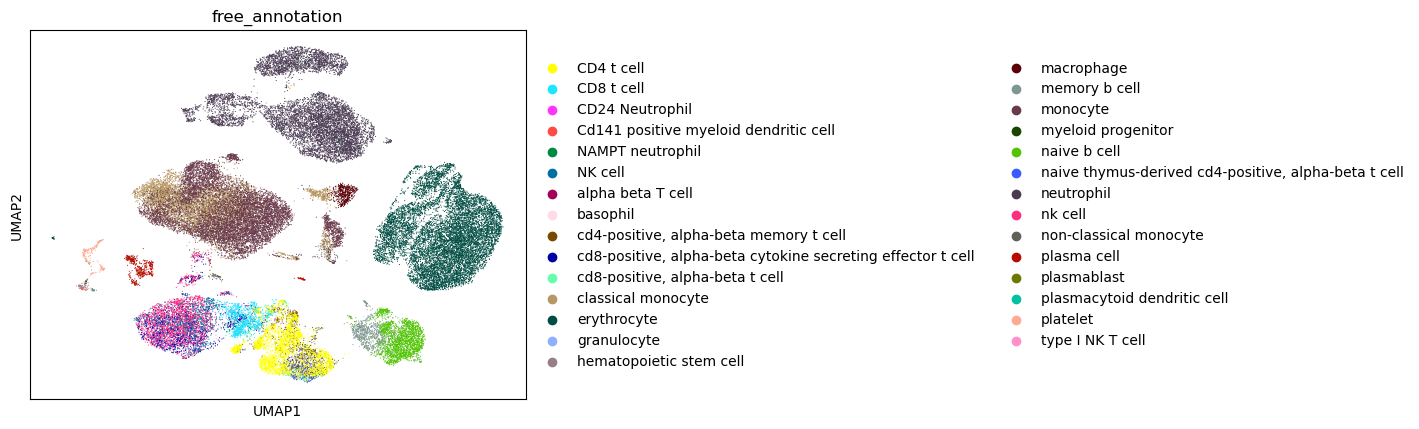

In [4]:
sc.pl.umap(
    adata,
    color=['free_annotation']
)

# A Star

In [5]:
# redefine the neighbors
sc.pp.neighbors(
    adata,
    n_neighbors=10,
    use_rep='X_scvi',
)

adata

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:25)


AnnData object with n_obs × n_vars = 50115 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'UMAP 1', 'UMAP 2'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap', 'free_annotation_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [6]:
def anndata_to_networkx(adata):
  """
  Converts an AnnData object with precomputed connectivities and distances 
  to a networkX graph. Adds all entries in adata.obs as node attributes.

  Args:
    adata: An AnnData object with 'connectivities' and 'distances' in obsp.

  Returns:
    A networkX graph object.
  """
  graph = nx.Graph()
  
  # Add nodes with attributes from adata.obs
  for i, cell_name in enumerate(adata.obs_names):
    graph.add_node(cell_name, **adata.obs.iloc[i].to_dict())

  # Add edges based on connectivities
  rows, cols = adata.obsp['connectivities'].nonzero()
  for i, j in zip(rows, cols):
    if i < j:  # Avoid adding duplicate edges
      weight = adata.obsp['distances'][i, j]
      graph.add_edge(adata.obs_names[i], adata.obs_names[j], weight=weight)

  return graph

G = anndata_to_networkx(adata)
print(G)

Graph with 50115 nodes and 325299 edges


In [7]:
def get_random_nodes(adata, source_type, target_type):
  """
  Selects a random source node and a random target node from an AnnData object.
  """
  source_node = random.choice(adata.obs[adata.obs['free_annotation'] == source_type].index)
  target_node = random.choice(adata.obs[adata.obs['free_annotation'] == target_type].index)
  return source_node, target_node


def compute_distance(source_node, target_node, obsm_key='X_pca'):
    """ The Euclidean distance between the two points.
    """
    source_coords = adata[source_node, :].obsm[obsm_key]
    target_coords = adata[target_node, :].obsm[obsm_key]
    distance = np.linalg.norm(source_coords - target_coords)
    return distance

source_type = "hematopoietic stem cell"
target_type = "macrophage"
obsm_key = 'X_pca'

source_node, target_node = get_random_nodes(
    adata, 
    source_type,
    target_type,
)

compute_distance(source_node, target_node)

49.617474

In [8]:
path = nx.astar_path(
    G, 
    source_node, 
    target_node,
    heuristic=compute_distance,
)

xdata = adata[path, :]
list(xdata.obs['free_annotation'].values)

['hematopoietic stem cell',
 'plasmacytoid dendritic cell',
 'plasmacytoid dendritic cell',
 'hematopoietic stem cell',
 'classical monocyte',
 'classical monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'monocyte',
 'classical monocyte',
 'classical monocyte',
 'classical monocyte',
 'monocyte',
 'macrophage',
 'macrophage',
 'macrophage',
 'macrophage',
 'macrophage',
 'macrophage']

In [9]:
def generate_paths(adata, G, source_type, target_type, n_paths=1, obsm_key='X_pca'):
    """
    Finds paths between source and target cell types in a graph and annotates an AnnData object.

    Args:
        adata: AnnData object containing single-cell data.
        G: NetworkX graph representing cell connectivity.
        source_type: String specifying the source cell type.
        target_type: String specifying the target cell type.
        n_paths: Number of paths to find.
        obsm_key: Key in `adata.obsm` containing the embedding for distance computation.

    Returns:
        pandas.DataFrame: DataFrame with path and path step annotations.
    """

    pdf = adata.obs.copy()
    pdf = pdf.reset_index()

    paths = []
    for i in range(n_paths):
        path_id = i + 1
        source_node, target_node = get_random_nodes(adata, source_type, target_type)
        path = nx.astar_path(G, source_node, target_node, heuristic=compute_distance)
        path_step = {x: i + 1 for i, x in enumerate(path)}

        tmp = pdf[pdf['cell_id'].isin(path)].reset_index()
        tmp['path_id'] = path_id
        tmp['path_step'] = tmp['cell_id'].map(path_step)
        paths.append(tmp)

    paths = pd.concat(paths)
    paths = paths.sort_values(by=['path_id', 'path_step'], ascending=[False, True])
    return paths

source_type = "hematopoietic stem cell"
target_type = "macrophage"
n_paths = 1

pdf = generate_paths(
    adata, 
    G, 
    source_type, 
    target_type, 
    n_paths, 
    obsm_key='X_pca',
)

pdf

,index,cell_id,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,UMAP 1,UMAP 2,path_id,path_step
10,28215,AACCTGAAGGTAGCAC_TSP14_Blood_NA_10X_3_1,Blood,10X,TSP14,nan,15646.0,4080,hematopoietic stem cell,hematopoietic stem cell,True,immune,male,-5.773230,-0.576183,1,1
3,22734,TCGGGACTCACGGTCG_TSP10_Blood_NA_10X_1_1_Enriched,Blood,10X,TSP10,nan,25429.0,4765,cd141-positive myeloid dendritic cell,Cd141 positive myeloid dendritic cell,True,immune,male,-5.873793,-0.552761,1,2
11,31240,GCCCGAATCGGATACT_TSP14_Blood_NA_10X_1_2,Blood,10X,TSP14,nan,16423.0,3599,cd141-positive myeloid dendritic cell,Cd141 positive myeloid dendritic cell,True,immune,male,-6.102139,-0.505439,1,3
22,46013,GGGTATTTCCAGCAAT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,15990.0,3089,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,-6.092592,-0.231466,1,4
25,47376,TTAGGCATCTGCATAG_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,9670.0,2616,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,-6.010218,-0.245957,1,5
2,14834,TACGGGCAGACAAGCC_TSP7_Blood_NA_10X_2_1,Blood,10X,TSP7,nan,14839.0,3835,cd141-positive myeloid dendritic cell,Cd141 positive myeloid dendritic cell,True,immune,female,-5.926784,-0.475673,1,6
1,9783,AGTTCGAAGTGCCGAA_TSP7_Blood_NA_10X_2_1,Blood,10X,TSP7,nan,22203.0,4467,plasmacytoid dendritic cell,plasmacytoid dendritic cell,True,immune,female,-5.279010,-0.644067,1,7
0,7698,TTCCACGCACTCCGGA_TSP7_Blood_NA_10X_1_1,Blood,10X,TSP7,nan,25375.0,4947,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,-5.161765,-0.612772,1,8
12,33682,GGAGAACCAAGTTTGC_TSP14_Blood_NA_10X_2_1,Blood,10X,TSP14,nan,17099.0,3717,classical monocyte,classical monocyte,True,immune,male,4.284661,3.724949,1,9
21,45568,GACCTTCAGTAACGAT_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,16778.0,3711,monocyte,monocyte,True,immune,female,4.188294,4.318958,1,10


([], [])

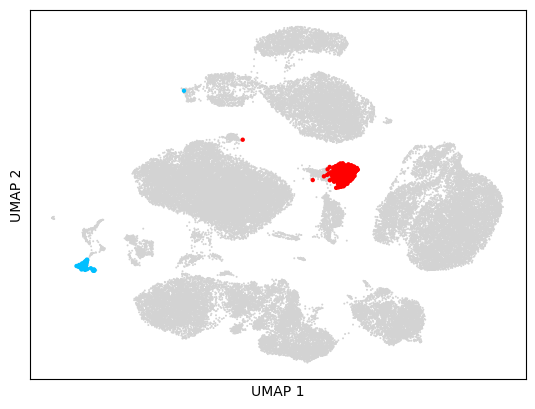

In [10]:
source_type = "hematopoietic stem cell"
target_type = "macrophage"

sns.scatterplot(
    data=adata.obs,
    x='UMAP 1',
    y='UMAP 2',
    c='lightgrey',
    ec='none',
    s=2,
    legend=False,
    zorder=2,
)

sns.scatterplot(
    data=adata.obs[adata.obs['free_annotation'] == source_type],
    x='UMAP 1',
    y='UMAP 2',
    c='deepskyblue',
    ec='none',
    s=10,
    legend=False,
    zorder=5,
)

sns.scatterplot(
    data=adata.obs[adata.obs['free_annotation'] == target_type],
    x='UMAP 1',
    y='UMAP 2',
    c='red',
    ec='none',
    s=10,
    legend=False,
    zorder=5,
)

plt.yticks([])
plt.xticks([])

# Single Path

/tmp/ipykernel_1903850/3928663764.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centroids = pdf.groupby('free_annotation').agg({'UMAP 1': 'mean', 'UMAP 2': 'mean'})


([], [])

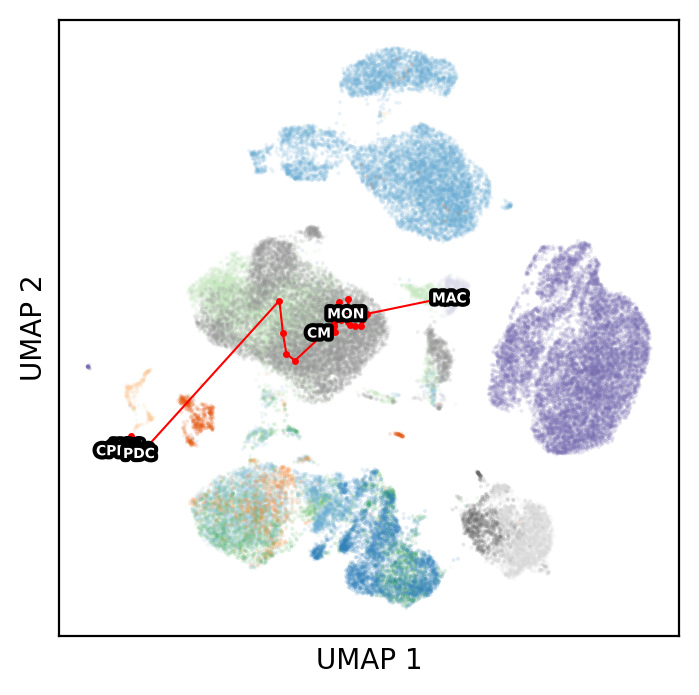

In [11]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

source_type = "hematopoietic stem cell"
target_type = "macrophage"
n_paths = 1

pdf = generate_paths(
    adata, 
    G, 
    source_type, 
    target_type, 
    n_paths, 
    obsm_key='X_scvi',
)

def abbreviate_cell_type(cell_type):
  """Abbreviates a cell type string."""
  words = cell_type.split()
  if len(words) == 1:
    return cell_type[:3].upper()  # Abbreviate single-word types to 3 letters
  else:
    return ''.join([word[0].upper() for word in words])  # Use first letter of each word

sns.scatterplot(
    data=adata.obs,
    x='UMAP 1',
    y='UMAP 2',
    hue='free_annotation',
    palette='tab20c',
    ec='none',
    alpha=0.15,
    s=2,
    legend=False,
    zorder=2,
)

# Calculate the centroids for each 'free_annotation' group
centroids = pdf.groupby('free_annotation').agg({'UMAP 1': 'mean', 'UMAP 2': 'mean'})
centroids = centroids.loc[pdf['free_annotation'].unique()]

# Annotate the centroids with bubble-like effect
for label, (x, y) in centroids.iterrows():
    plt.text(x, y, abbreviate_cell_type(label), 
             ha='center', 
             va='center', 
             fontsize=5, 
             fontweight='bold',
             zorder=10,
             color='w', 
             path_effects=[
                 patheffects.Stroke(linewidth=3, foreground='black'),  # Thicker black outline
                 patheffects.Normal()  # Render original text on top
             ])

sns.lineplot(
    data=pdf.sort_values(by='path_step'),
    x='UMAP 1',
    y='UMAP 2',
    c='r',
    lw=0.75,
    legend=False,
    zorder=3,
    marker='.',
    markersize=5,
    markeredgecolor='none',
)

plt.yticks([])
plt.xticks([])

# Multiple Paths

In [12]:
source_type = "hematopoietic stem cell"
target_type = "macrophage"
n_paths = 100

pdf = generate_paths(
    adata, 
    G, 
    source_type, 
    target_type, 
    n_paths, 
    obsm_key='X_scvi',
)

print(f"{pdf.shape=}")
pdf.head()

pdf.shape=(3060, 17)


,index,cell_id,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,manually_annotated,compartment,gender,UMAP 1,UMAP 2,path_id,path_step
5,28215,AACCTGAAGGTAGCAC_TSP14_Blood_NA_10X_3_1,Blood,10X,TSP14,nan,15646.0,4080,hematopoietic stem cell,hematopoietic stem cell,True,immune,male,-5.773230,-0.576183,100,1
4,22734,TCGGGACTCACGGTCG_TSP10_Blood_NA_10X_1_1_Enriched,Blood,10X,TSP10,nan,25429.0,4765,cd141-positive myeloid dendritic cell,Cd141 positive myeloid dendritic cell,True,immune,male,-5.873793,-0.552761,100,2
27,46814,TCATTACTCGCGAAGA_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,19759.0,4241,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,-5.985069,-0.427901,100,3
30,47376,TTAGGCATCTGCATAG_TSP2_Blood_NA_10X_2_1,Blood,10X,TSP2,nan,9670.0,2616,hematopoietic stem cell,hematopoietic stem cell,True,immune,female,-6.010218,-0.245957,100,4
3,14834,TACGGGCAGACAAGCC_TSP7_Blood_NA_10X_2_1,Blood,10X,TSP7,nan,14839.0,3835,cd141-positive myeloid dendritic cell,Cd141 positive myeloid dendritic cell,True,immune,female,-5.926784,-0.475673,100,5


([], [])

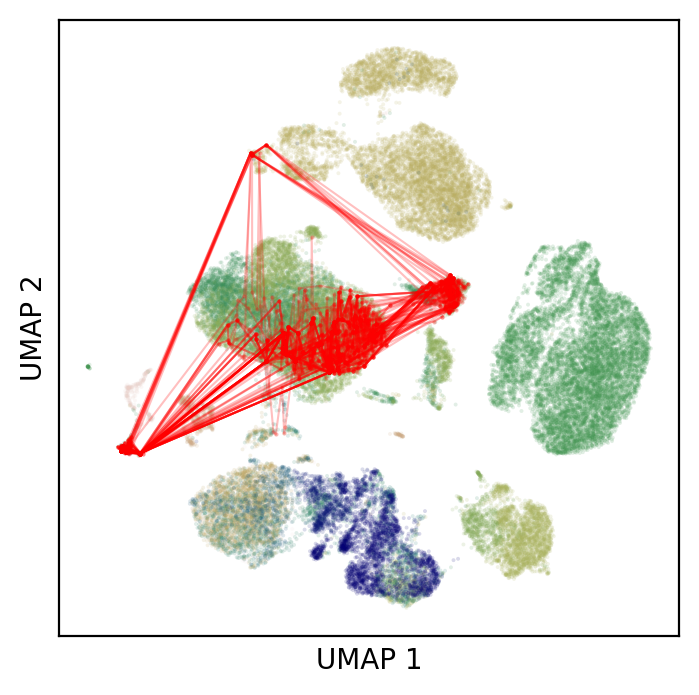

In [13]:
sns.scatterplot(
    data=adata.obs,
    x='UMAP 1',
    y='UMAP 2',
    hue='free_annotation',
    palette='gist_earth',
    ec='none',
    alpha=0.15,
    s=2,
    legend=False,
    zorder=2,
)    



for path, group in pdf.groupby('path_id'):
    if path == 0: # skip the no path cells
        continue

    x = group['UMAP 1'].values
    y = group['UMAP 2'].values

    geometry = list(zip(x, y))
    geometry = simplify_coords(geometry, 0.1)    
    x_smooth, y_smooth = zip(*geometry)
    
    sns.lineplot(
        x=x_smooth, 
        y=y_smooth,
        c='r',
        lw=0.75,
        alpha=0.25,
        marker='.',
        markersize=3,
        markeredgecolor='none',
    )

plt.yticks([])
plt.xticks([])

# visualize all paths

In [14]:
cell_idx = pdf['cell_id'].unique()
bdata = adata[cell_idx, :].copy()
bdata

AnnData object with n_obs × n_vars = 952 × 58870
    obs: 'organ_tissue', 'method', 'donor', 'anatomical_information', 'n_counts_UMIs', 'n_genes', 'cell_ontology_class', 'free_annotation', 'manually_annotated', 'compartment', 'gender', 'UMAP 1', 'UMAP 2'
    var: 'gene_symbol', 'feature_type', 'ensemblid', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: '_scvi', '_training_mode', 'cell_ontology_class_colors', 'dendrogram_cell_type_tissue', 'dendrogram_computational_compartment_assignment', 'dendrogram_consensus_prediction', 'dendrogram_tissue_cell_type', 'donor_colors', 'donor_method_colors', 'hvg', 'method_colors', 'neighbors', 'organ_tissue_colors', 'sex_colors', 'tissue_colors', 'umap', 'free_annotation_colors'
    obsm: 'X_pca', 'X_scvi', 'X_scvi_umap', 'X_umap'
    layers: 'decontXcounts', 'raw_counts'
    obsp: 'connectivities', 'distances'

In [15]:
# sce.tl.palantir(
#     bdata,
#     n_components=5,
#     knn=5,
# )

# sc.pp.neighbors(
#     bdata,
#     use_rep='X_palantir_multiscale'
# )

# sc.tl.umap(
#     bdata,
# )

# sc.pl.umap(
#     bdata,
#     color=['free_annotation'],
#     palette='tab20c',
#     ncols=1,
# )

In [16]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Analyze known genes

In [ ]:
adata

X.shape=(36, 1214)


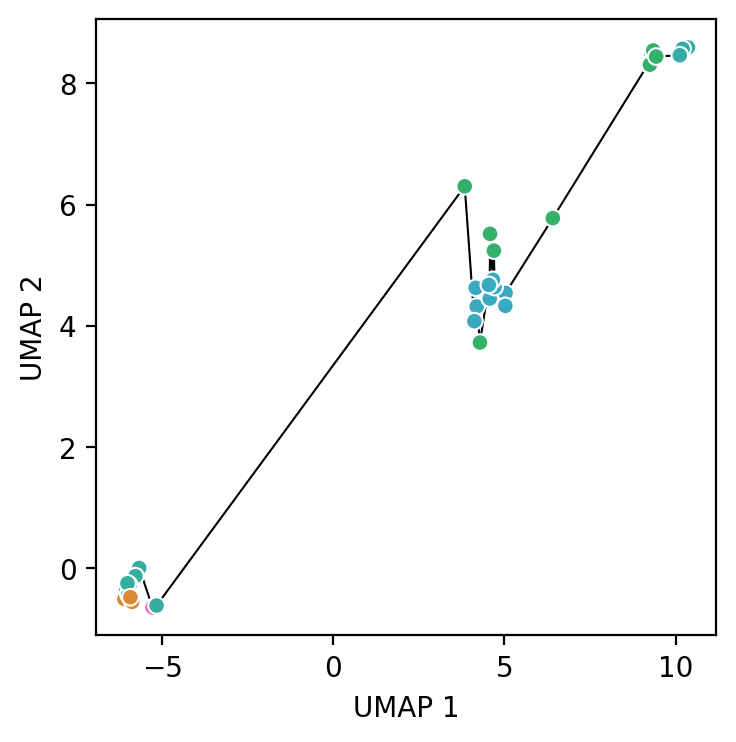

In [17]:
path_id = 5
trajectory = pdf[pdf['path_id'] == path_id]
cell_idx = trajectory['cell_id'].values
gene_idx = adata.var[adata.var['highly_variable']].index

sns.lineplot(
    data=trajectory,
    x='UMAP 1', 
    y='UMAP 2',
    lw=0.75,
    c='k',
    legend=False,
    zorder=1,
)

sns.scatterplot(
    data=trajectory,
    x='UMAP 1', 
    y='UMAP 2',
    lw=0.75,
    hue='free_annotation',
    legend=False,
    zorder=5,
)

X = adata[cell_idx, gene_idx].to_df()
X = X.loc[:, X.sum() != 0]
X = X.loc[:, X.std() != 0]
print(f"{X.shape=}")

(36, 20)


<Axes: >

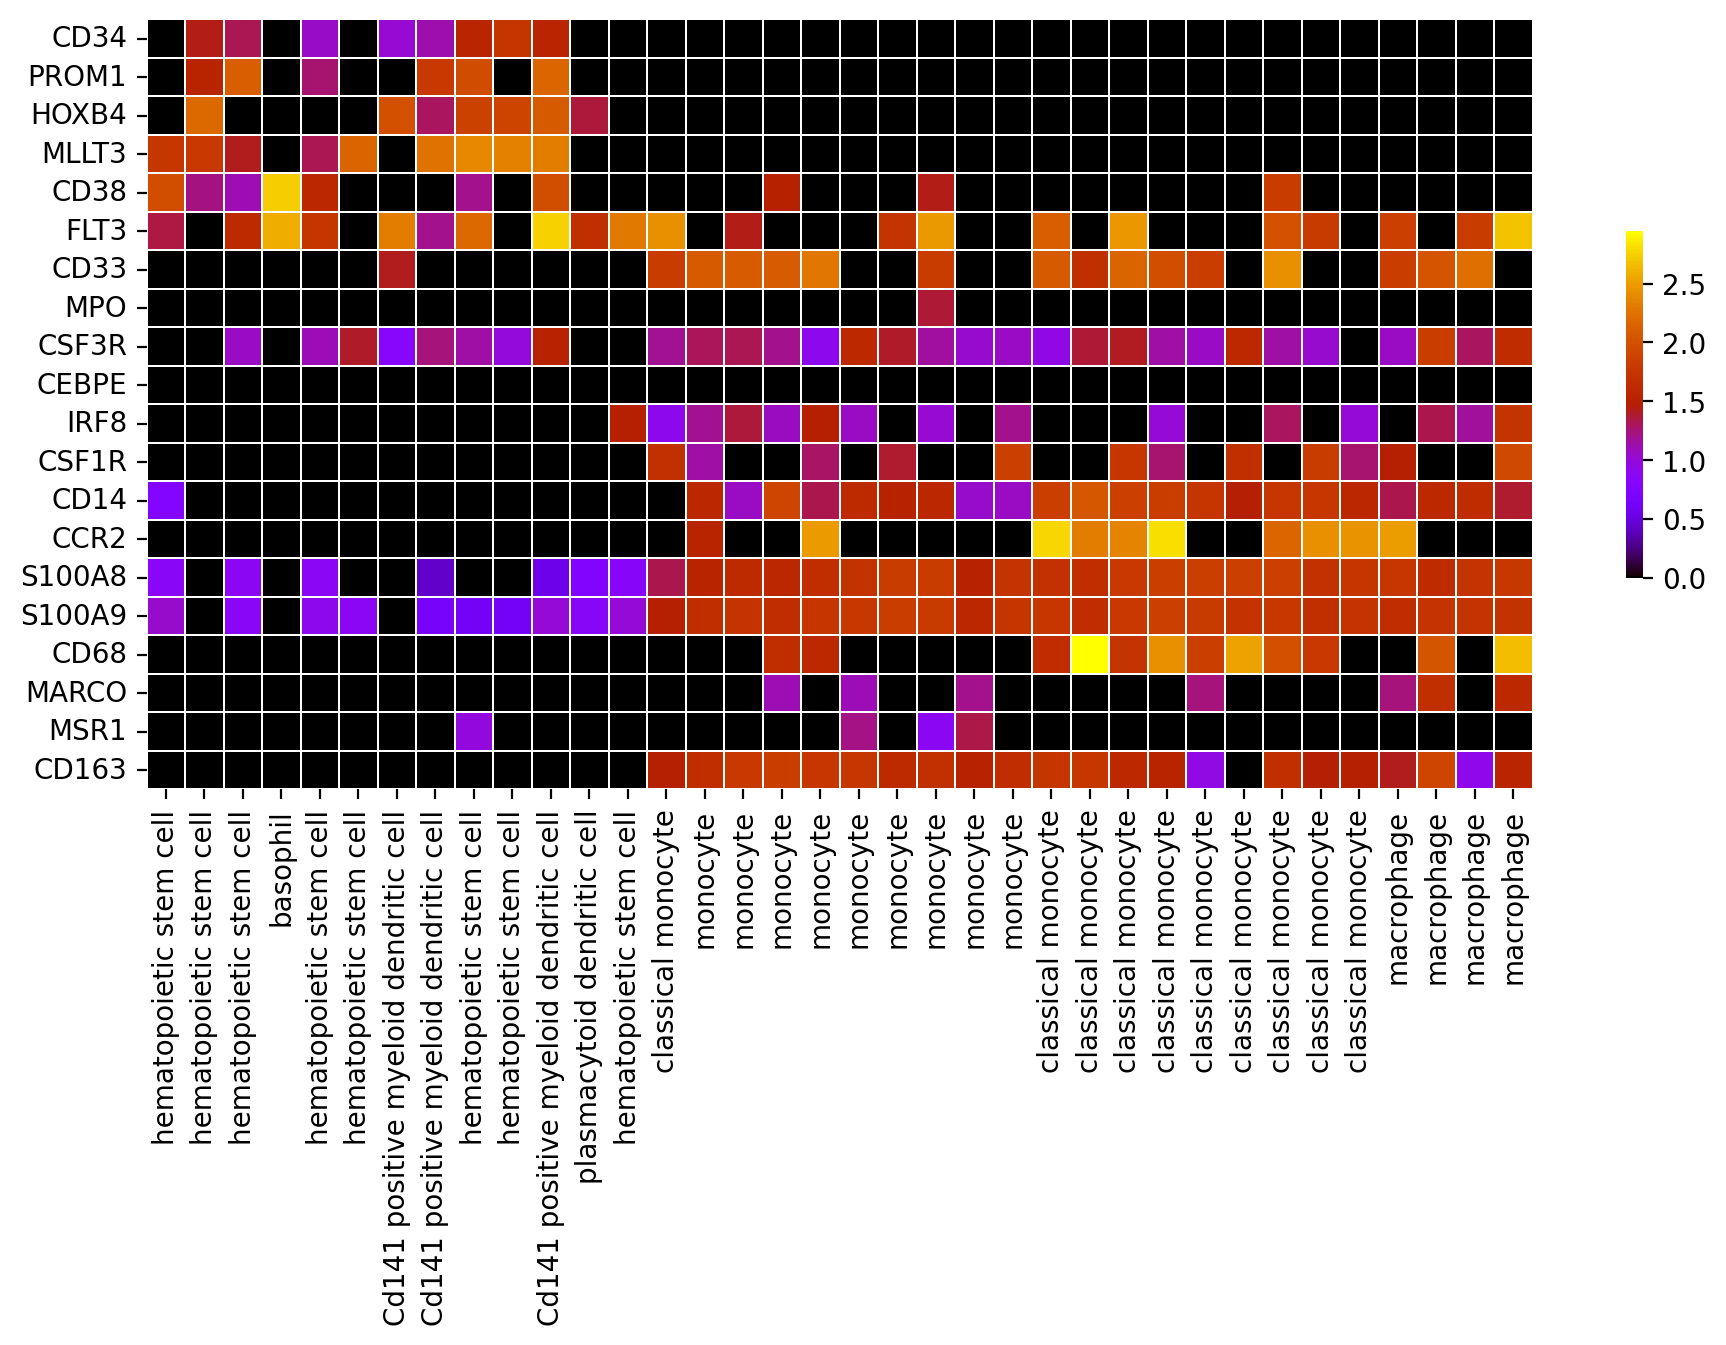

In [18]:
gene_list = [
      # Hematopoietic Stem Cell (HSC)
    "CD34",  # Cell surface marker, highly enriched in HSCs
    "CD133", # Another HSC marker, though expression can change with differentiation
    "PROM1",  #  (CD133)
    "HOXB4",  #  Transcription factor, important for HSC self-renewal
    "MLLT3",  #  (AF9): Involved in HSC self-renewal and leukemogenesis

    # Multipotent Progenitor (MPP)
    "CD38",  #  Expressed as HSCs differentiate towards MPPs
    "FLT3",  #  Receptor tyrosine kinase, important for MPP expansion
    "CD45RA", #  Isoform of CD45, expression changes during early differentiation

    # Common Myeloid Progenitor (CMP)
    "CD33",  #  Myeloid lineage marker, expressed on CMPs
    "MPO",    #  Myeloperoxidase, enzyme found in myeloid cells, starts to be expressed

    # Granulocyte-Macrophage Progenitor (GMP)
    "CSF3R",  #  Receptor for G-CSF, essential for granulocyte development
    "CEBPE",  #  C/EBPε: Transcription factor, more specific to granulocyte lineage

    # Monocyte-Dendritic Cell Progenitor (MDP)
    "IRF8",   #  Important for both monocyte and DC development, but with distinct roles
    "CSF1R",  #  Expression increases as cells commit to monocyte lineage

    # Monocyte
    "CD14",   #  Cell surface marker for monocytes/macrophages
    "CCR2",   #  Receptor for CCL2, mediates monocyte migration
    "S100A8", #  (MRP8): Calcium-binding protein, expressed in monocytes and neutrophils
    "S100A9", #  (MRP14):  Forms a complex with S100A8, similar function

    # Macrophage
    "CD68",   #  Lysosomal marker, highly expressed in macrophages
    "MARCO",  #  Scavenger receptor, involved in phagocytosis
    "MSR1",   #  Macrophage scavenger receptor 1, another phagocytic receptor
    "CD163",  #  Scavenger receptor for hemoglobin-haptoglobin complexes
]

X = adata[cell_idx, :].to_df()
columns = [x for x in gene_list if x in X.columns]
X = X[columns]
X.index = trajectory['free_annotation'].values
print(f"{X.shape}")

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (X.shape[0] / 3), (X.shape[1] / 4)

sns.heatmap(
    data=np.sqrt(X.T),
    square=True,
    lw=0.15,
    cmap='gnuplot',
    cbar_kws={'shrink' : 0.45},
)

<Axes: >

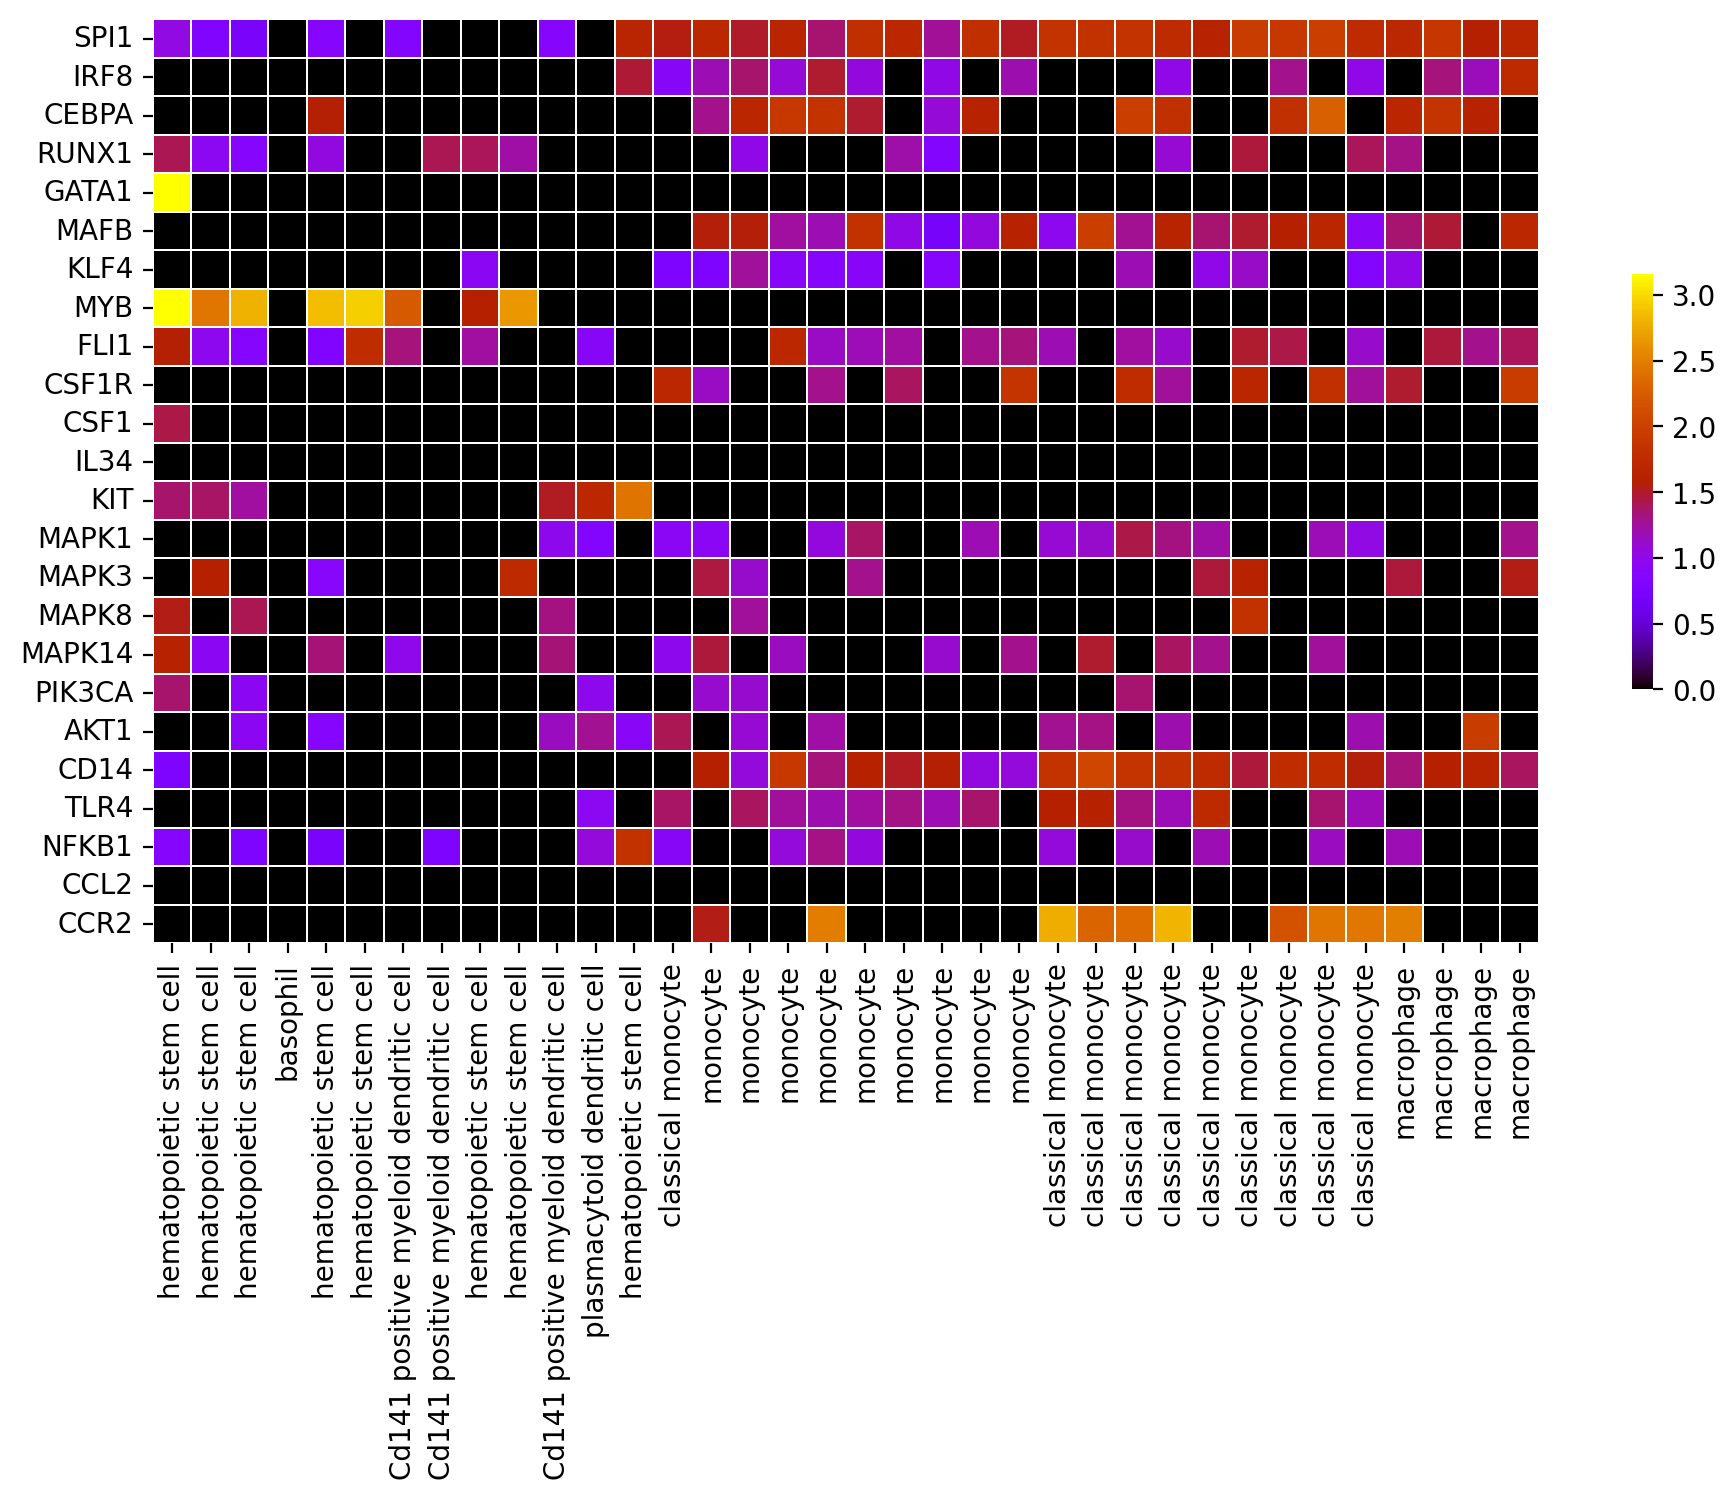

In [19]:
gene_list = [
    # Transcription Factors
    "SPI1",  # PU.1: Essential for myeloid lineage commitment
    "IRF8",  # Works with PU.1, important for macrophage function
    "CEBPA",  # C/EBPα: Essential for granulocyte/macrophage progenitors
    "RUNX1",  # Broad hematopoietic regulator, including early myeloid development
    "GATA1",  # Suppresses alternative fates, indirectly supporting macrophage development
    "MAFB",  # Promotes late-stage differentiation and specific functions
    "KLF4",  # Complex role, both promoting and suppressing aspects depending on context
    "MYB",    #  Involved in HSC self-renewal and differentiation, influences myeloid lineage
    "FLI1",   #  ETS family transcription factor, role in macrophage differentiation and inflammatory response

    # Growth Factors and Receptors
    "CSF1R",  # Receptor for CSF1, essential for macrophage survival and differentiation
    "CSF1",  # Ligand for CSF1R, promotes macrophage development
    "IL34",  # Alternative ligand for CSF1R, also promotes macrophage development
    "KIT",    #  Receptor tyrosine kinase, involved in early hematopoiesis and macrophage progenitor survival

    # Signaling Molecules
    "MAPK1",  # ERK1:  MAPK pathway component, involved in differentiation signals
    "MAPK3",  # ERK2:  MAPK pathway component, involved in differentiation signals
    "MAPK8",  # JNK1:  MAPK pathway component, involved in differentiation signals
    "MAPK14", # p38α: MAPK pathway component, involved in differentiation signals
    "PIK3CA", # PI3K subunit, crucial for survival and proliferation signals
    "AKT1",   # AKT:  Downstream effector of PI3K, involved in survival and proliferation

    # Other Important Genes
    "CD14",   #  Cell surface marker for monocytes/macrophages, involved in LPS recognition
    "TLR4",   #  Toll-like receptor 4, recognizes LPS and triggers inflammatory responses
    "NFKB1",  #  NF-κB subunit, key regulator of inflammation and immune responses in macrophages
    "CCL2",   #  Chemokine (MCP-1), recruits monocytes to sites of inflammation
    "CCR2",   #  Receptor for CCL2, mediates monocyte migration
]

X = adata[cell_idx, :].to_df()
columns = [x for x in gene_list if x in X.columns]
X = X[columns]
X.index = trajectory['free_annotation'].values

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (X.shape[0] / 3), (X.shape[1] / 4)

sns.heatmap(
    data=np.sqrt(X.T),
    square=True,
    lw=0.15,
    cmap='gnuplot',
    cbar_kws={'shrink' : 0.45},
)

# DMD on trajectories

In [20]:
path_id = 5
trajectory = pdf[pdf['path_id'] == path_id]
cell_idx = trajectory['cell_id'].values
gene_idx = adata.var[adata.var['highly_variable']].index

X = adata[cell_idx, gene_idx].to_df()
X = X.loc[:, X.sum() != 0]
X = X.loc[:, X.std() != 0]
X = X.T
print(f"{X.shape=}")

X.shape=(1214, 36)


In [21]:
def compute_dmd(X):
    """
    Compute Dynamic Mode Decomposition (DMD) of data matrix X.

    Args:
        X: Data matrix (rows: variables, columns: timesteps).

    Returns:
        A: System dynamics matrix.
        eigenvalues: Eigenvalues of A, sorted in descending order by the 
                     magnitude of the real part (for complex eigenvalues).
        W: Corresponding eigenvectors of A.
    """
    X1 = X[:, :-1]
    X2 = X[:, 1:]
    A = X2 @ np.linalg.pinv(X1)
    eigenvalues, W = np.linalg.eig(A)

    # Sort eigenvalues and eigenvectors by descending magnitude of real part
    real_magnitudes = np.abs(np.real(eigenvalues))  # Magnitudes of real parts
    idx = np.argsort(real_magnitudes)[::-1]  # Indices that sort by magnitude in descending order
    eigenvalues = eigenvalues[idx]
    W = W[:, idx]

    return A, eigenvalues, W


A, eigenvalues, W = compute_dmd(X.to_numpy())
print(f"{A.shape=}")
print(f"{eigenvalues.shape=}")
print(f"{W.shape=}")

A.shape=(1214, 1214)
eigenvalues.shape=(1214,)
W.shape=(1214, 1214)


In [ ]:
# def plot_dmd_eigenvalues(eigenvalues):
#     """
#     Plot DMD eigenvalues on the complex plane and as a bar plot of real parts.

#     Args:
#         eigenvalues: Eigenvalues computed from DMD.
#     """
#     t = np.linspace(0, np.pi * 2, 100)
#     plt.rcParams['figure.dpi'] = 300
#     plt.rcParams['figure.figsize'] = 7, 3
#     fig, axs = plt.subplots(1, 2)

#     print(f"{np.real(eigenvalues).max()=}")
#     pdf = pd.DataFrame({'real': np.real(eigenvalues),
#                         'imaginary': np.imag(eigenvalues)})
#     print(f"{pdf.shape=}")
#     pdf['mode'] = list(range(1, len(pdf) + 1))

#     # Plot real parts
#     sns.barplot(data=pdf,
#                 x='mode',
#                 y='real',
#                 hue='mode',
#                 ax=axs[0],
#                 dodge=False,
#                 ec='k',
#                 palette='tab20')
#     axs[0].legend().remove()
#     axs[0].axhline(y=0, zorder=1, lw=0.75, c='k')
#     axs[0].set_xlabel("Mode")
#     axs[0].set_ylabel(r'$\mathregular{Re(\lambda)}$')

#     # Plot eigenvalues on the unit circle
#     axs[1].plot(np.cos(t),
#                  np.sin(t),
#                  linewidth=1,
#                  c='k',
#                  zorder=1)
#     sns.scatterplot(data=pdf,
#                     x='real',
#                     y='imaginary',
#                     s=100,
#                     marker=".",
#                     hue='mode',
#                     ax=axs[1],
#                     ec='k',
#                     palette='tab20',
#                     zorder=3)

#     # Add axes
#     axs[1].axvline(x=0, ls=":", c='grey', zorder=0)
#     axs[1].axhline(y=0, ls=":", c='grey', zorder=0)
#     axs[1].set_aspect('equal')
#     axs[1].set_xlabel(r'$\mathregular{Re(\lambda)}$')
#     axs[1].set_ylabel(r'$\mathregular{Im(\lambda)}$')
#     sns.move_legend(axs[1],
#                     title='Mode',
#                     frameon=False,
#                     loc='upper right',
#                     markerscale=0.5,
#                     bbox_to_anchor=(1.4, 1.1))
#     sns.despine()
#     plt.tight_layout()
#     plt.show()

# n_val = 10
# evals = eigenvalues[:n_val]
# plot_dmd_eigenvalues(evals)

# Hasnain-like Sensor Selection

In [22]:
def compute_reduced_dmd(X, r):
  """
  Computes the reduced DMD model using 'r' principal components.

  Args:
    X: Data matrix (rows: variables, columns: timesteps).
    r: Number of principal components to use for reduction.

  Returns:
    Ar: Reduced system dynamics matrix.
    eigenvalues_r: Eigenvalues of Ar.
    Wr: Corresponding eigenvectors of Ar.
    Ur: The projection matrix 
  """

  # 1. Perform Singular Value Decomposition (SVD) on X
  U, S, Vh = np.linalg.svd(X)

  # 2. Construct the projection matrix from the first r columns of U
  Ur = U[:, :r]

  # 3. Project the data matrix X onto the r-dimensional subspace
  Xr = Ur.T @ X

  # 4. Compute DMD on the reduced data matrix Xr
  Ar, eigenvalues_r, Wr = compute_dmd(Xr)

  return Ar, eigenvalues_r, Wr, Ur


Ar, eigenvaluesr, Wr, Ur = compute_reduced_dmd(X.to_numpy(), r=5)
print(f"{Ar.shape=}")
print(f"{eigenvaluesr.shape=}")
print(f"{Wr.shape=}")
print(f"{Ur.shape=}")

Ar.shape=(5, 5)
eigenvaluesr.shape=(5,)
Wr.shape=(5, 5)
Ur.shape=(1214, 5)


In [23]:
# build the initial condition matrix:
# cell cells of the source data type are used 

def make_X0(adata, source_type):
    """A function to extract a matrix representing the 
    initial condition"""
    return adata[adata.obs['free_annotation'] == source_type, :].to_df().T
    
X0 = make_X0(adata, source_type)
X0 = X0[X0.index.isin(X.index)] # filter for same genes in same order
print(f"{X0.shape=}")

# project onto the low-dimensional DMD coords
X0r = Ur.T @ X0
print(f"{X0r.shape=}")

X0.head()

X0.shape=(1214, 70)
X0r.shape=(5, 70)


cell_id,ACTTTGTAGCTGTTAC_TSP7_Blood_NA_10X_1_1,AGCGTATTCTGGTCAA_TSP7_Blood_NA_10X_1_1,AGGTTGTCAGGATGAC_TSP7_Blood_NA_10X_1_1,ATCGGATCAGAGCTAG_TSP7_Blood_NA_10X_1_1,CAATCGATCACATCAG_TSP7_Blood_NA_10X_1_1,CAGTTCCTCGAGTTGT_TSP7_Blood_NA_10X_1_1,CCGTAGGCAGGAGGTT_TSP7_Blood_NA_10X_1_1,CCTCCAAGTCTGCGCA_TSP7_Blood_NA_10X_1_1,CCTCTCCGTTGTGTAC_TSP7_Blood_NA_10X_1_1,CTGCAGGGTCCACATA_TSP7_Blood_NA_10X_1_1,...,GGCTGTGAGGTACTGG_TSP2_Blood_NA_10X_2_1,GGGTATTTCCAGCAAT_TSP2_Blood_NA_10X_2_1,TCATTACTCGCGAAGA_TSP2_Blood_NA_10X_2_1,TGTGATGCATCGCCTT_TSP2_Blood_NA_10X_2_1,TTAGGCATCTGCATAG_TSP2_Blood_NA_10X_2_1,TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_B12_S36,TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_F22_S142,TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_H13_S181,TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_L12_S276,TSP2_Blood_NA_SS2_B113459_B133094_LinNeg_M10_S298
AL627309.6,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
MTCO1P12,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.298064,0.000000,0.000000,0.000000,...,0.0,0.0,0.63696,0.65818,0.0,0.961393,1.117217,0.230809,0.153682,0.641939
ISG15,0.0,0.555671,0.000000,1.030999,0.000000,0.00000,0.000000,0.465850,0.798851,0.682376,...,0.0,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
CCNL2,0.0,0.000000,1.360359,0.000000,0.954878,0.90569,1.290278,0.000000,0.000000,0.000000,...,0.0,0.0,0.00000,0.00000,0.0,0.000000,3.414408,2.476433,0.000000,0.463371
NADK,0.0,0.762215,0.980169,0.000000,0.000000,0.00000,0.502121,0.639008,0.000000,0.000000,...,0.0,0.0,0.00000,0.00000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000


In [25]:
def gram_matrix(A, X0, U, k=100):
    """
    Computes the Gram matrix for a given DMD operator and initial conditions.
    
    Args:
        A: Matrix representation of the Koopman operator.
        x0: Initial conditions from measurements.
        projection_matrix: Matrix for projecting data and Koopman operator.
        k: Number of time points to compute the Gram matrix.
        
    Returns:
        Returns the full Gram matrix, estimated from the reduced model
    """
    # Compute Gram matrix
    G = sum(np.linalg.matrix_power(A, i) @ X0 @ X0.T @ np.linalg.matrix_power(A, i).T for i in range(k))
    G = U @ G @ U.T
    return G

G = gram_matrix(Ar, X0r, Ur)
print(f"{G.shape=}")

G.shape=(1214, 1214)


In [26]:
D, V = np.linalg.eig(G)
print(f"{D.shape=}{ V.shape=}")

obs = pd.DataFrame({
    'gene_name' : X.index,
    'is_tf' : X.index.isin(tf_list),
    'ev1' : V[:,0],
    'weight' : np.abs(np.real(V[:,0])),
    'weight_rel' : np.real(V[:,0]),
})

obs['rank'] = obs['weight'].rank(ascending=False)
obs = obs.sort_values(by='rank', ascending=True)

obs.head(10)

D.shape=(1214,) V.shape=(1214, 1214)


,gene_name,is_tf,ev1,weight,weight_rel,rank
798,RNASE2,False,-0.176596+0.000000j,0.176596,-0.176596,1.0
565,FCN1,False,-0.141988+0.000000j,0.141988,-0.141988,2.0
1187,CFP,False,-0.138193+0.000000j,0.138193,-0.138193,3.0
748,LYZ,False,-0.136313+0.000000j,0.136313,-0.136313,4.0
349,VCAN,False,-0.125282+0.000000j,0.125282,-0.125282,5.0
403,AIF1,False,-0.119455+0.000000j,0.119455,-0.119455,6.0
461,MYO1G,False,-0.117812+0.000000j,0.117812,-0.117812,7.0
1045,C19orf38,False,-0.115819+0.000000j,0.115819,-0.115819,8.0
402,LST1,False,-0.113044+0.000000j,0.113044,-0.113044,9.0
69,S100A12,False,-0.110419+0.000000j,0.110419,-0.110419,10.0


In [30]:
n_genes = 30
database = 'ontology'

edf = gget.enrichr(obs['gene_name'].head(n_genes).to_list(), database=database)
pd.set_option('display.max_colwidth', 100)
edf[['path_name', 'adj_p_val', 'overlapping_genes']].head(10)

Wed Mar 26 12:34:18 2025 INFO Performing Enichr analysis using database GO_Biological_Process_2021. 
    Please note that there might a more appropriate database for your application. 
    Go to https://maayanlab.cloud/Enrichr/#libraries for a full list of supported databases.
    


,path_name,adj_p_val,overlapping_genes
0,neutrophil degranulation (GO:0043312),3.213349e-13,"[FCN1, FCER1G, STXBP2, CYBB, RNASE2, LYZ, CFP, FGR, S100A12, MNDA, FOLR3, CD14, CTSD, CTSB]"
1,neutrophil activation involved in immune response (GO:0002283),3.213349e-13,"[FCN1, FCER1G, STXBP2, CYBB, RNASE2, LYZ, CFP, FGR, S100A12, MNDA, FOLR3, CD14, CTSD, CTSB]"
2,neutrophil mediated immunity (GO:0002446),3.213349e-13,"[FCN1, FCER1G, STXBP2, CYBB, RNASE2, LYZ, CFP, FGR, S100A12, MNDA, FOLR3, CD14, CTSD, CTSB]"
3,innate immune response (GO:0045087),4.218732e-08,"[FGR, FCN1, FCER1G, NCF2, RNASE6, CYBB, S100A12, RNASE2, CFP]"
4,defense response to bacterium (GO:0042742),5.350949e-07,"[FGR, FCER1G, RNASE6, S100A12, RNASE2, LYZ, CFP]"
5,defense response to Gram-positive bacterium (GO:0050830),2.522467e-04,"[FGR, RNASE6, RNASE2, LYZ]"
6,positive regulation of cytokine production (GO:0001819),5.485492e-04,"[FGR, FCN1, FCER1G, HMOX1, CD14, AIF1]"
7,cellular response to oxidative stress (GO:0034599),1.888467e-03,"[NCF2, CYBB, HMOX1, AIF1]"
8,pattern recognition receptor signaling pathway (GO:0002221),4.937898e-03,"[FCN1, CD14, CTSB]"
9,Fc-gamma receptor signaling pathway (GO:0038094),6.583391e-03,"[FGR, FCER1G, MYO1G]"


In [31]:
obs[obs['is_tf']].head(10)

,gene_name,is_tf,ev1,weight,weight_rel,rank
246,HCLS1,True,-0.082348+0.000000j,0.082348,-0.082348,30.0
1122,MAFB,True,-0.073247+0.000000j,0.073247,-0.073247,44.0
812,FOS,True,-0.058460+0.000000j,0.058460,-0.058460,76.0
693,FLI1,True,-0.046916+0.000000j,0.046916,-0.046916,121.0
731,NFE2,True,-0.044353+0.000000j,0.044353,-0.044353,133.0
974,STAT5A,True,-0.038867+0.000000j,0.038867,-0.038867,159.0
932,IRF8,True,-0.036721+0.000000j,0.036721,-0.036721,171.0
557,HSPA5,True,-0.035631+0.000000j,0.035631,-0.035631,178.0
387,SOX4,True,-0.034750+0.000000j,0.034750,-0.034750,184.0
211,UBP1,True,-0.030691+0.000000j,0.030691,-0.030691,223.0


# Aggregrate Results

In [32]:
results = []

rank = 5
gene_idx = adata.var[adata.var['highly_variable']].index
X0 = make_X0(adata, source_type)
print(f"{X0.shape=}")


for path_id, trajectory in pdf.groupby('path_id'):
    cell_idx = trajectory['cell_id'].values

    X = adata[cell_idx, gene_idx].to_df()
    X = X.T
    print(f"{path_id=} {X.shape=}")

    # compute the DMD
    Ar, eigenvaluesr, Wr, Ur = compute_reduced_dmd(X.to_numpy(), r=rank)

    # project onto the low-dimensional DMD coords
    X0r = Ur.T @ X0[X0.index.isin(X.index)]
    G = gram_matrix(Ar, X0r, Ur, k=5)
    D, V = np.linalg.eig(G)

    # observability gram matrix
    obs = pd.DataFrame({
        'gene_name' : X.index,
        'is_tf' : X.index.isin(tf_list),
        'ev1' : V[:,0],
        'weight' : np.abs(np.real(V[:,0])),
        'weight_rel' : np.real(V[:,0]),
    })
    
    obs['rank'] = obs['weight'].rank(ascending=False)
    obs = obs.sort_values(by='rank', ascending=True)
    obs['path_id'] = path_id
    results.append(obs)


results = pd.concat(results)
results.head()

X0.shape=(58870, 70)
path_id=1 X.shape=(2435, 26)
path_id=2 X.shape=(2435, 37)
path_id=3 X.shape=(2435, 16)
path_id=4 X.shape=(2435, 53)
path_id=5 X.shape=(2435, 36)
path_id=6 X.shape=(2435, 16)
path_id=7 X.shape=(2435, 39)
path_id=8 X.shape=(2435, 19)
path_id=9 X.shape=(2435, 19)
path_id=10 X.shape=(2435, 33)
path_id=11 X.shape=(2435, 28)
path_id=12 X.shape=(2435, 35)
path_id=13 X.shape=(2435, 36)
path_id=14 X.shape=(2435, 29)
path_id=15 X.shape=(2435, 26)
path_id=16 X.shape=(2435, 38)
path_id=17 X.shape=(2435, 31)
path_id=18 X.shape=(2435, 27)
path_id=19 X.shape=(2435, 38)
path_id=20 X.shape=(2435, 49)
path_id=21 X.shape=(2435, 45)
path_id=22 X.shape=(2435, 23)
path_id=23 X.shape=(2435, 44)
path_id=24 X.shape=(2435, 16)
path_id=25 X.shape=(2435, 12)
path_id=26 X.shape=(2435, 38)
path_id=27 X.shape=(2435, 31)
path_id=28 X.shape=(2435, 21)
path_id=29 X.shape=(2435, 31)
path_id=30 X.shape=(2435, 11)
path_id=31 X.shape=(2435, 45)
path_id=32 X.shape=(2435, 36)
path_id=33 X.shape=(2435, 45

,gene_name,is_tf,ev1,weight,weight_rel,rank,path_id
604,SPINK2,False,0.220782+0.000000j,0.220782,0.220782,1.0,1
2224,AVP,False,0.201318+0.000000j,0.201318,0.201318,2.0,1
729,CRHBP,False,0.182739+0.000000j,0.182739,0.182739,3.0,1
1150,HEMGN,False,0.136836+0.000000j,0.136836,0.136836,4.0,1
584,CYTL1,False,0.136610+0.000000j,0.136610,0.136610,5.0,1


In [33]:
tdf = pd.pivot_table(
    results, 
    index='gene_name',
    columns='path_id',
    values='rank',
    aggfunc='mean',
    fill_value=None,
)

tdf['score'] = tdf.mean(axis=1)
tdf = tdf.sort_values(by='score')
tdf = tdf.reset_index(drop=False)
tdf['is_tf'] = tdf['gene_name'].isin(tf_list)

tdf[['gene_name', 'score', 'is_tf']].head(15)

path_id,gene_name,score,is_tf
0,AIF1,13.880,False
1,SH3BGRL,20.700,False
2,LST1,36.890,False
3,CD74,40.600,False
4,DAZAP2,41.740,False
5,SOX4,42.110,True
6,FERMT3,54.160,False
7,HCLS1,55.480,True
8,PRR13,56.690,False
9,RCSD1,56.740,False


In [34]:
tdf[tdf['is_tf']][['gene_name', 'score', 'is_tf']].head(15)

path_id,gene_name,score,is_tf
5,SOX4,42.110,True
7,HCLS1,55.480,True
23,BCL11A,92.610,True
42,FOS,125.050,True
79,ELF2,177.020,True
81,KDM5A,183.480,True
91,STAT5A,195.070,True
94,FLI1,195.860,True
96,NFE2,197.780,True
109,PHTF1,216.160,True


<Axes: >

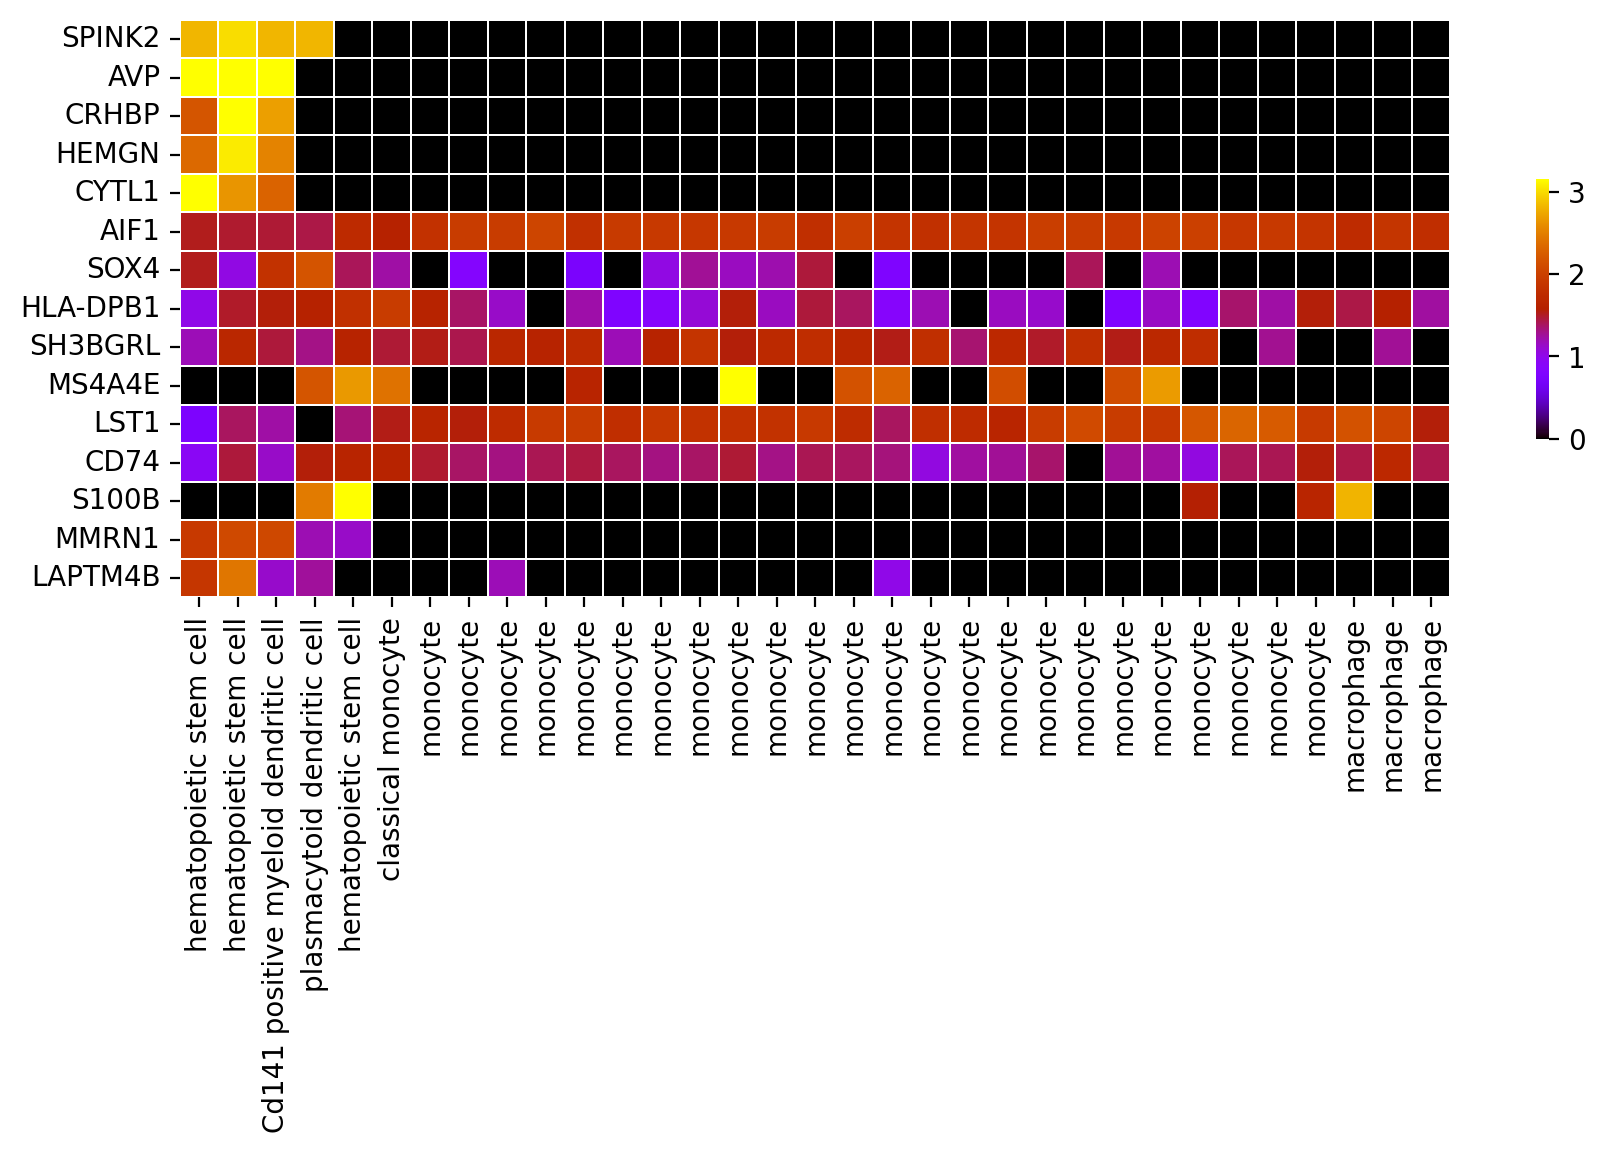

In [35]:
path_id = 10
trajectory = pdf[pdf['path_id'] == path_id]
cell_idx = trajectory['cell_id'].values

gene_list = results['gene_name'].head(15).to_list()

X = adata[cell_idx, :].to_df()
columns = [x for x in gene_list if x in X.columns]
X = X[columns]
X.index = trajectory['free_annotation'].values

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (X.shape[0] / 3), (X.shape[1] / 4)

sns.heatmap(
    data=np.sqrt(X.T),
    square=True,
    lw=0.15,
    cmap='gnuplot',
    cbar_kws={'shrink' : 0.45},
)

<Axes: >

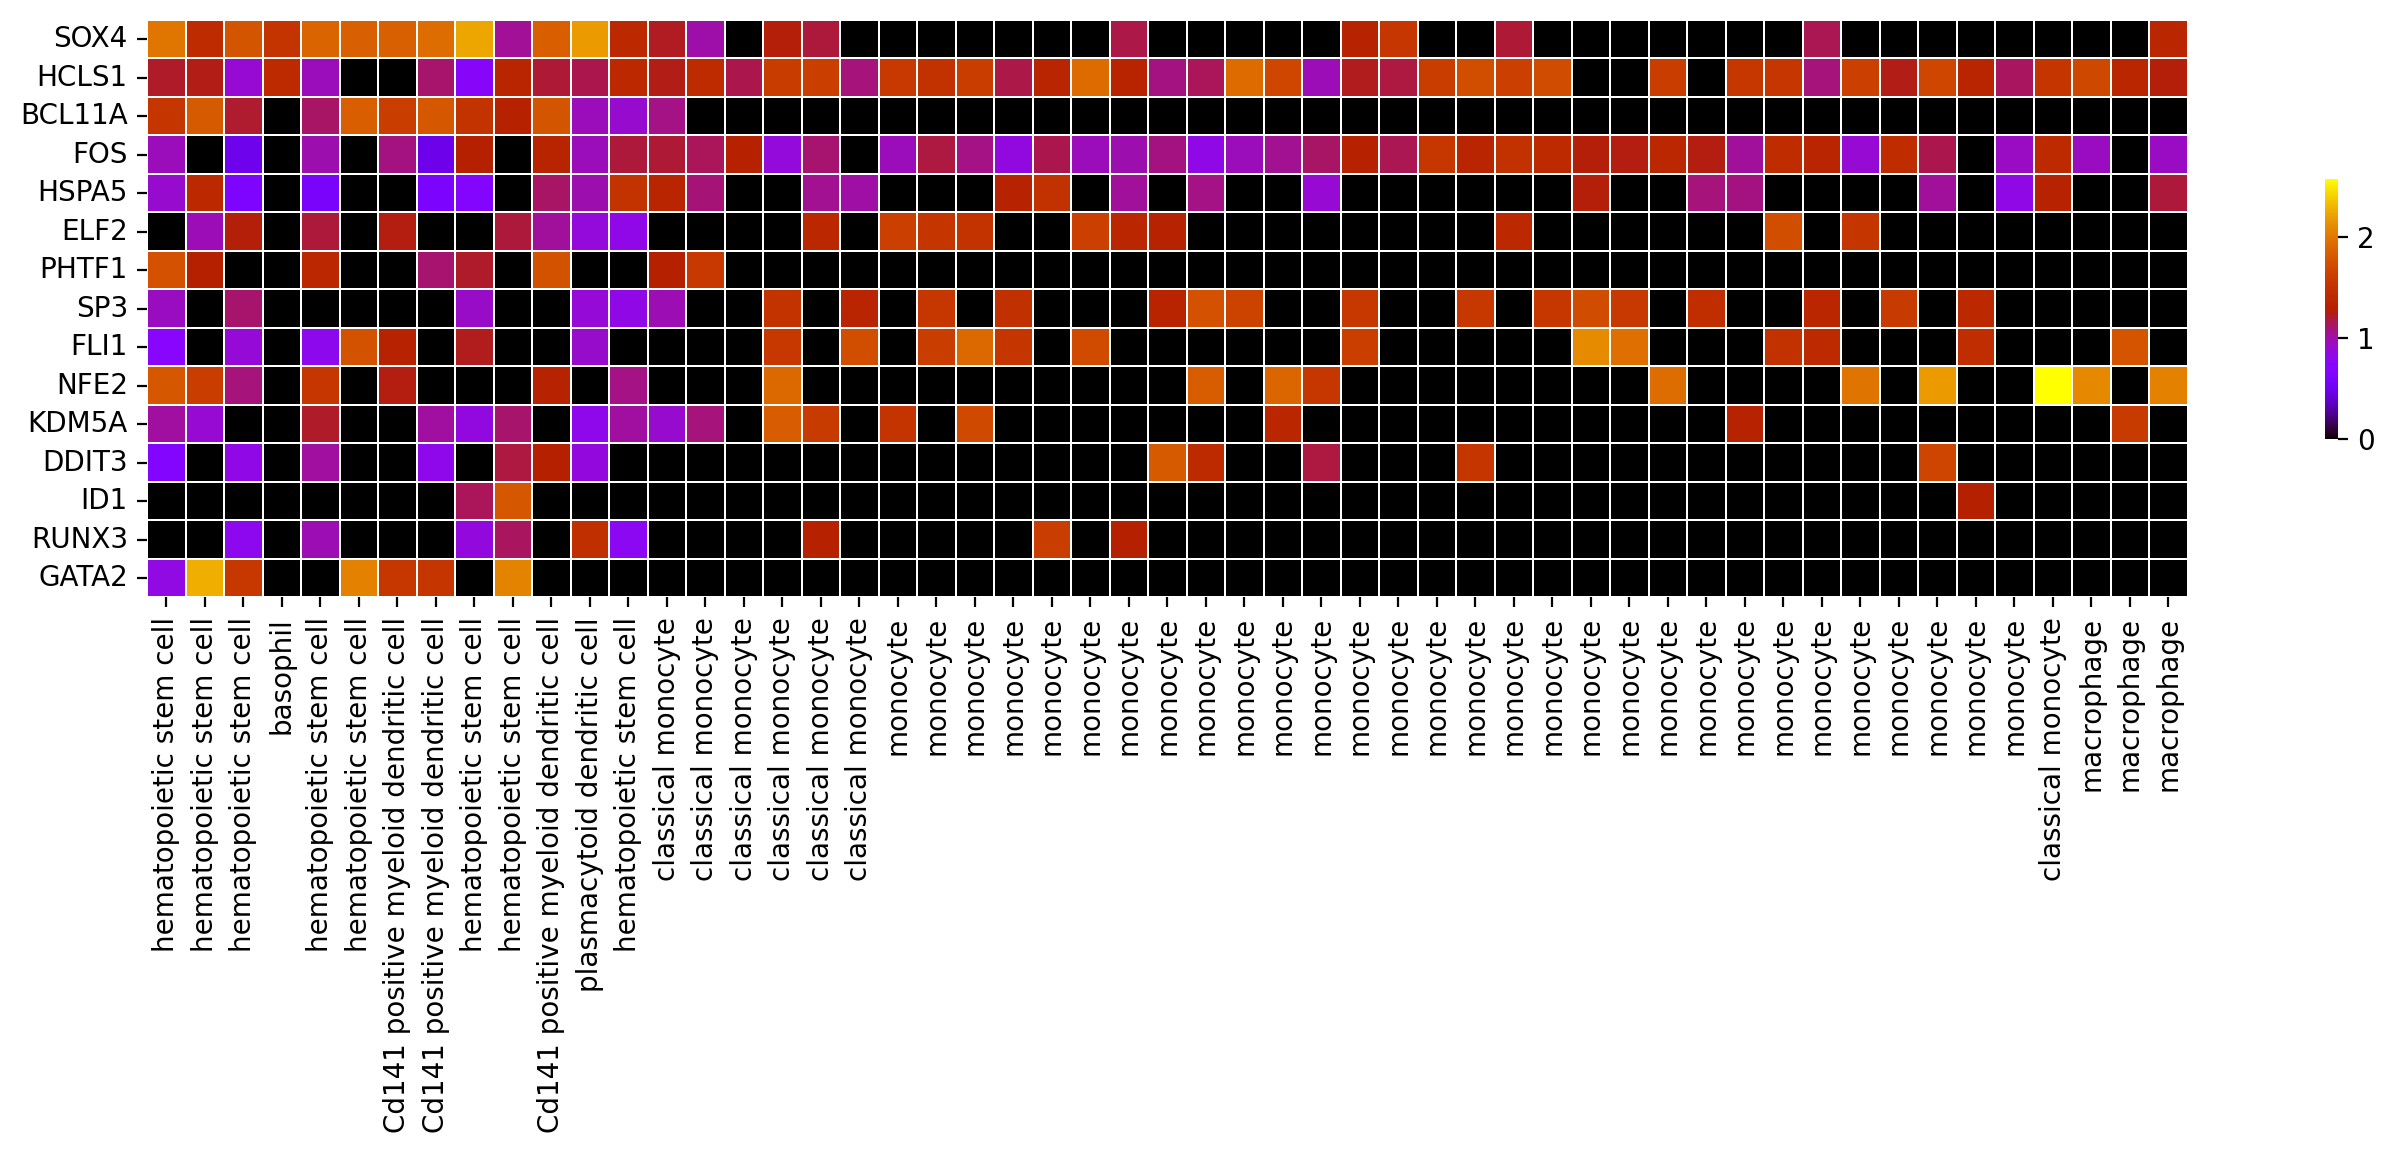

In [36]:
path_id = 4
trajectory = pdf[pdf['path_id'] == path_id]
cell_idx = trajectory['cell_id'].values

gene_list = results[results['is_tf']]['gene_name'].head(15).to_list()

X = adata[cell_idx, :].to_df()
columns = [x for x in gene_list if x in X.columns]
X = X[columns]
X.index = trajectory['free_annotation'].values

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = (X.shape[0] / 3), (X.shape[1] / 4)

sns.heatmap(
    data=np.sqrt(X.T),
    square=True,
    lw=0.15,
    cmap='gnuplot',
    cbar_kws={'shrink' : 0.45},
)

In [ ]:
break

# Data Guided-Control

In [37]:
# load the B matrix and structure accordingly
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/data/scenic_resources/10kbp_up_10kbp_down_B.csv"

B = pd.read_csv(fpath)
print(f"raw {B.shape=}")
B = B.rename(columns={'Unnamed: 0' : 'gene_name'})
B = B.set_index('gene_name')

# drop zero sum TFs
B = B.loc[:, B.sum() != 0]

B = B.loc[B.index.isin(adata.var_names), B.columns.isin(adata.var_names)]
B_full = B.copy()

B = B.loc[B.index.isin(gene_idx), B.columns.isin(gene_idx)]

print(f"filtered {B_full.shape=} (hvg: {B.shape=}) ")
B.head()

raw B.shape=(27090, 1606)
filtered B_full.shape=(23871, 1436) (hvg: B.shape=(2015, 86)) 


,ADNP2,ATF3,ATF7,BCL11A,BCL6,CREB5,CREM,DDIT3,EBF4,ELF2,...,ZNF552,ZNF563,ZNF583,ZNF621,ZNF624,ZNF674,ZNF774,ZNF778,ZNF860,ZSCAN22
gene_name,,,,,,,,,,,,,,,,,,,,,
A2M,0.564,4.246060,4.136609,6.938889,6.219429,1.57850,4.115739,2.7400,2.278,4.766669,...,1.536,1.906700,0.000,0.0,1.44250,0.0795,3.9600,2.82500,4.615,0.000
A2ML1,1.310,5.061273,5.094870,7.826667,7.569428,1.19800,5.138348,2.8450,3.538,6.443553,...,2.580,2.159333,3.270,0.0,1.48525,1.1450,3.7455,4.29750,3.675,0.635
AATK,4.020,6.196212,6.913739,6.955555,6.018286,3.86000,6.930696,4.3300,7.248,5.290428,...,2.250,5.320000,2.215,0.0,2.02675,0.0000,5.6975,5.31750,2.605,0.000
ABCA13,5.600,5.325215,5.550744,5.492222,5.333800,1.59355,5.546396,2.5915,4.616,4.046551,...,1.902,5.096667,0.685,0.0,1.70750,2.2450,3.0675,2.42600,2.515,0.000
ABCA2,4.450,4.737379,6.178043,4.151333,3.610714,3.01250,6.198478,3.5700,4.706,2.750510,...,1.086,3.653333,0.000,0.0,0.83000,0.0000,4.3205,1.74375,3.575,0.000


In [38]:
def controllability_matrix(A, B, k):
  """
  Calculates the controllability matrix for a given system.

  Args:
    A: The state matrix.
    B: The input matrix.
    k: The number of terms to include in the matrix.

  Returns:
    The controllability matrix.
  """

  A = np.array(A)
  B = np.array(B)
  n = A.shape[0]  # Number of states

  C = np.zeros((n, k * B.shape[1]))
  C[:, :B.shape[1]] = B

  for i in range(1, k):
    C[:, i * B.shape[1]:(i + 1) * B.shape[1]] = A @ C[:, (i - 1) * B.shape[1]:i * B.shape[1]]

  return C


def mu1_distance(C, z, xF, xI, A, k):
  """
  Computes the distance mu_1(B) as defined in the equation.

  Args:
    C: The controllability matrix.
    z: The target state vector.
    xF: The final state vector.
    xI: The initial state vector.
    A: The state matrix.
    k: The number of terms used to construct C.

  Returns:
    The calculated distance mu_1(B).
  """

  C_plus = np.linalg.pinv(C)  # Moore-Penrose pseudoinverse of C
  I = np.eye(C.shape[0])      # Identity matrix

  term1 = C @ C_plus - I
  term2 = xF - np.linalg.matrix_power(A, k) @ xI

  distance = np.linalg.norm(term1 @ term2, 2)  # 2-norm of the result

  return distance    

In [ ]:
break

In [39]:
def compute_observability_gramian(A, C, truncate=25):
    """
    Compute the observability gramian for system (A, C).

    Args:
        A: System dynamics matrix.
        C: Output matrix.
        truncate: Number of terms for truncation if using 'summation' method.

    Returns:
        Observability Gramian W_O.
    """
    W_O = np.zeros((A.shape[0], A.shape[0]))
    for k in range(truncate):
        W_O += (np.linalg.matrix_power(A, k).T) @ C.T @ C @ np.linalg.matrix_power(A, k)
    return W_O

C = X[X.columns[0]].to_numpy().reshape(1, -1)
print(f"{C.shape=}")
print(f"{A.shape=}")

W_O = compute_observability_gramian(A, C) 
print(f"{W_O.shape=}")

G = pd.DataFrame(W_O, index=X.index, columns=X.index)
G.head()

C.shape=(1, 53)
A.shape=(1214, 1214)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 53 is different from 1214)

# Sensor selection

In [ ]:
D, V = np.linalg.eig(G)
print(f"{D.shape=}{ V.shape=}")

obs = pd.DataFrame({
    'gene_name' : X.index,
    'is_tf' : X.index.isin(tf_list),
    'ev1' : V[:,0],
    'weight' : np.abs(np.real(V[:,0])),
    'weight_rel' : np.real(V[:,0]),
})

obs['rank'] = obs['weight'].rank(ascending=False)
obs = obs.sort_values(by='rank', ascending=True)

obs.head(10)

In [ ]:
n_genes = 10
database = 'ontology'

edf = gget.enrichr(obs['gene_name'].head(n_genes).to_list(), database=database)
edf[['path_name', 'adj_p_val', 'adj_p_val']].head()

In [ ]:
obs[obs['is_tf']].head(10)

In [ ]:
# break

# aggregate the results

In [ ]:
results = []

gene_idx = adata.var[adata.var['highly_variable']].index

for path_id, trajectory in pdf.groupby('path_id'):
    cell_idx = trajectory['cell_id'].values

    X = adata[cell_idx, gene_idx].to_df()
    X = X.T
    print(f"{path_id=} {X.shape=}")

    # compute the DMD
    A, eigenvalues, W = compute_dmd(X.to_numpy())

    # compute the observability grammian
    x0 = X[X.columns[0]].to_numpy().reshape(1, -1)
    W = compute_observability_gramian(A, x0, truncate=10) 

    D, V = np.linalg.eig(W)
    print(f"{D.shape=}{ V.shape=}")
    
    obs = pd.DataFrame({
        'gene_name' : X.index,
        'is_tf' : X.index.isin(tf_list),
        'ev1' : V[:,0],
        'weight' : np.abs(np.real(V[:,0])),
        'weight_rel' : np.real(V[:,0]),
    })
    
    obs['rank'] = obs['weight'].rank(ascending=False)
    obs = obs.sort_values(by='rank', ascending=True)
    obs['path_id'] = path_id

    results.append(obs)


results = pd.concat(results)
results.head()

In [ ]:
tdf = pd.pivot_table(
    results, 
    index='gene_name',
    columns='path_id',
    values='rank',
    aggfunc='mean',
    fill_value=None,
)

tdf['score'] = tdf.mean(axis=1)
tdf = tdf.sort_values(by='score')
tdf = tdf.reset_index(drop=False)
tdf['is_tf'] = tdf['gene_name'].isin(tf_list)

tdf[['gene_name', 'score', 'is_tf']].head(15)

In [ ]:
tdf[tdf['is_tf']][['gene_name', 'score', 'is_tf']].head(15)

# Archive

In [ ]:
break

In [ ]:
sc.tl.diffmap(adata)
sc.pp.neighbors(adata, n_neighbors=10, use_rep="X_diffmap")

In [ ]:
target = "hematopoietic stem cell"
adata.uns["iroot"] = np.flatnonzero(adata.obs["free_annotation"] == target)[0]
sc.tl.dpt(adata)

adata

In [ ]:
sc.pl.umap(
    adata,
    color=['free_annotation', 'dpt_pseudotime'],
    ncols=1,
)